In [55]:
#pip install yfinance

In [1]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timedelta
from datetime import date

/Users/mattzidell/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
def vol_check():
    tickers = input("provide tickers to visualize volatility: ").replace(" ","")
    
    ticker_list = tickers.split(",")
    for i in range(len(ticker_list)):
        ticker_list[i] = ticker_list[i].upper()
    
    today = date.today()
    lookback = (str(today.year-2)+'-'+str(today.month)+'-'+str(today.day))
    lookback_date = datetime.strptime(lookback, '%Y-%m-%d').date()
    
    plt.figure(figsize=(12, 6))
    
    for i in range(len(ticker_list)):
        data = yf.download(ticker_list[i], start=lookback_date, end=today-timedelta(days=1))
        data.reset_index()
        data['log_close']=np.log(data['Close'])
        data['log_returns'] = data['log_close']-data['log_close'].shift(1)
        data['std_dev'] = data['log_returns'].rolling(30,axis=0).std() 
    
        plt.title("Volatility of Selected Equities, 30 Day Rolling Window")
        plt.plot(data['std_dev'])
        plt.xticks(rotation=25)
        plt.xlabel("Date")
        plt.ylabel("Std. Dev. of Ticker Returns")
        plt.legend(ticker_list,loc='upper right')
    
        plt.tight_layout()  

[*********************100%***********************]  1 of 1 completed
/var/folders/x3/2hzhwqqs64bg9zlfssbvx_1m0000gn/T/ipykernel_40568/3331442578.py:19: FutureWarning: The 'axis' keyword in Series.rolling is deprecated and will be removed in a future version. Call the method without the axis keyword instead.
  data['std_dev'] = data['log_returns'].rolling(30,axis=0).std()
[*********************100%***********************]  1 of 1 completed
/var/folders/x3/2hzhwqqs64bg9zlfssbvx_1m0000gn/T/ipykernel_40568/3331442578.py:19: FutureWarning: The 'axis' keyword in Series.rolling is deprecated and will be removed in a future version. Call the method without the axis keyword instead.
  data['std_dev'] = data['log_returns'].rolling(30,axis=0).std()
[*********************100%***********************]  1 of 1 completed
/var/folders/x3/2hzhwqqs64bg9zlfssbvx_1m0000gn/T/ipykernel_40568/3331442578.py:19: FutureWarning: The 'axis' keyword in Series.rolling is deprecated and will be removed in a future ve

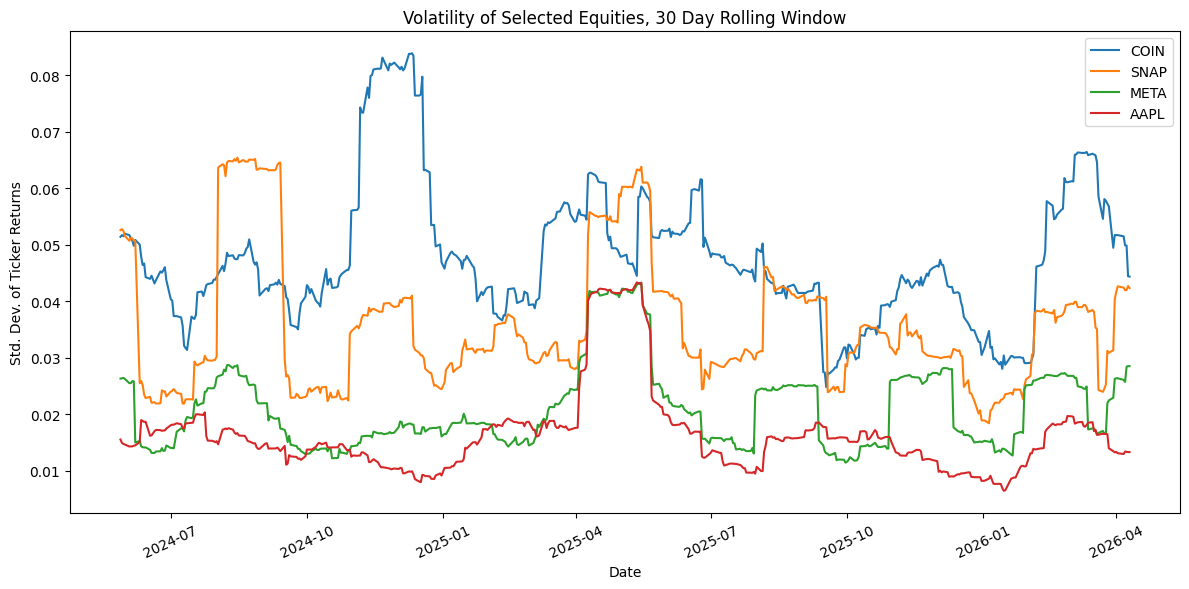

In [6]:
vol_check()